# Route A - TF-IDF Encoder, and Various Classifiers

### Load data

In [1]:
import os, re, html, pickle, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

from collections import Counter
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import f1_score, classification_report, confusion_matrix

SEED      = 42
MODEL_OUT = "route_a.model"

In [2]:
data = pd.read_csv("splits/data_split.csv", index_col=0)
data["clean_eda"] = data["clean_eda"].fillna("").astype(str)
data["sentiment"] = data["sentiment"].astype(int)

print("Loaded:", len(data), "documents")
print(data["split"].value_counts().to_string())
print("\nClass balance overall:")
print(data["sentiment"].value_counts(normalize=True).sort_index().round(3).to_string())

Loaded: 255083 documents
split
train    178557
val       38263
test      38263

Class balance overall:
sentiment
-1    0.352
 0    0.249
 1    0.399


## 7/ Route A tokenization and plot diagnostics

#### (1) Remove stopwords, (2) lemmatize each words

In [3]:
nltk.download("stopwords", quiet=True)
nltk.download("wordnet",   quiet=True)
nltk.download("omw-1.4",  quiet=True)

# Keep negation words — removing them would destroy sentiment signal.
_base_stop  = set(stopwords.words("english"))
_keep_words = {"not", "no", "nor", "never", "none", "n't", "very",
               "too", "so", "but", "however", "although"}
STOP_A      = _base_stop - _keep_words
_lemmatizer = WordNetLemmatizer()

print(f"Stopword list size: {len(STOP_A)} (after keeping negations)")

Stopword list size: 191 (after keeping negations)


#### (3) Tokenize route A and (4) remove empty documents

In [4]:
def tokenize_A(text: str, min_len: int = 2) -> list:
    """Route A tokenizer: stopword removal + lemmatization (noun + verb pass)."""
    toks = re.findall(r"[a-z]+", text)               # extract letter sequences
    toks = [t for t in toks if t not in STOP_A]      # remove stopwords
    toks = [t for t in toks if len(t) >= min_len]    # min length filter
    toks = [_lemmatizer.lemmatize(t) for t in toks]  # noun form
    toks = [_lemmatizer.lemmatize(t, pos="v") for t in toks]  # verb form
    toks = [t for t in toks if t not in STOP_A]      # re-filter after lemma
    return toks

data["tokens_A"]   = data["clean_eda"].map(tokenize_A)
data["n_tokens_A"] = data["tokens_A"].map(len)

empty_A = data["n_tokens_A"] == 0
print(f"Docs with 0 Route-A tokens: {empty_A.sum():,} ({empty_A.mean()*100:.2f}%)")
data = data[~empty_A].reset_index(drop=True)

train_df = data[data["split"] == "train"].reset_index(drop=True)
val_df   = data[data["split"] == "val"].reset_index(drop=True)
test_df  = data[data["split"] == "test"].reset_index(drop=True)

print(f"train: {len(train_df):,}   val: {len(val_df):,}   test: {len(test_df):,}")

Docs with 0 Route-A tokens: 4 (0.00%)
train: 178,554   val: 38,263   test: 38,262


### 6.2/ Train-only diagnostics

#### (1) Visualise again Zipf function, and (2) plot Coverage curve

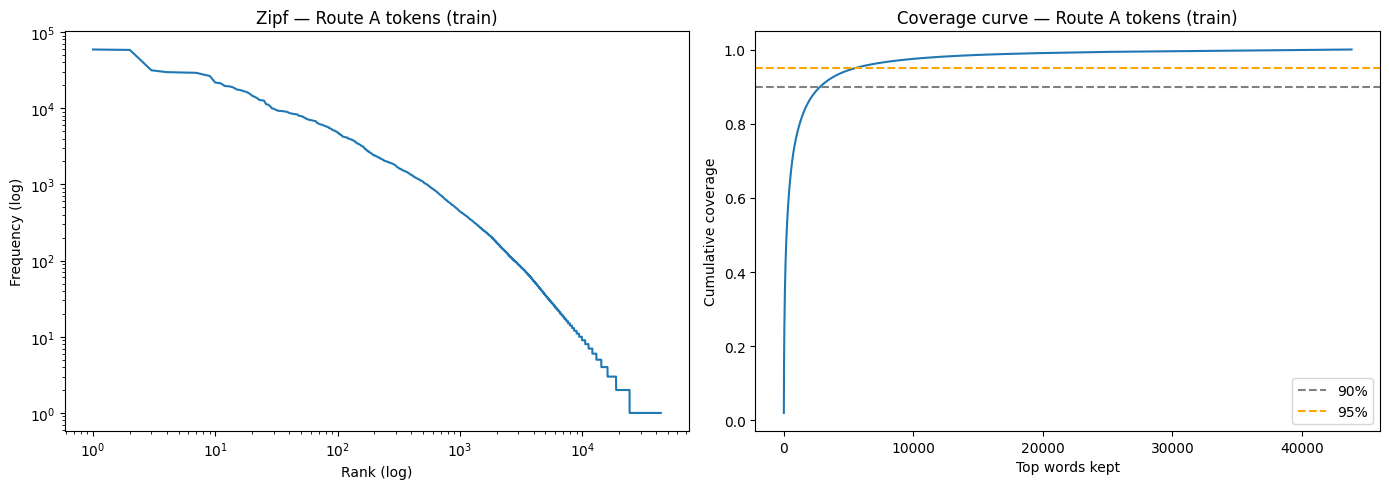

  90% coverage -> top 2,815 words
  95% coverage -> top 5,523 words
  99% coverage -> top 19,324 words

Train vocabulary size: 43,832


In [5]:
# Vocabulary coverage curve -> data-driven feature-count hand-off (TRAIN ONLY)
all_tokens_A = [t for toks in train_df["tokens_A"] for t in toks]
vocab_A      = Counter(all_tokens_A)
freqs_A      = np.array(sorted(vocab_A.values(), reverse=True))
ranks_A      = np.arange(1, len(freqs_A) + 1)
cum_A        = np.cumsum(freqs_A) / freqs_A.sum()

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].loglog(ranks_A, freqs_A)
axs[0].set_xlabel("Rank (log)"); axs[0].set_ylabel("Frequency (log)")
axs[0].set_title("Zipf — Route A tokens (train)")
axs[1].plot(ranks_A, cum_A)
axs[1].axhline(0.90, ls="--", color="grey",   label="90%")
axs[1].axhline(0.95, ls="--", color="orange", label="95%")
axs[1].set_xlabel("Top words kept"); axs[1].set_ylabel("Cumulative coverage")
axs[1].set_title("Coverage curve — Route A tokens (train)"); axs[1].legend()
plt.tight_layout(); plt.show()

COVERAGE_FEATURES = {p: int(np.searchsorted(cum_A, p) + 1) for p in (0.90, 0.95, 0.99)}
for p, n in COVERAGE_FEATURES.items():
    print(f"  {p*100:.0f}% coverage -> top {n:,} words")
print(f"\nTrain vocabulary size: {len(vocab_A):,}")

1. Coverage curves provide strict feature cap which guarantee a huge dimension reduction in the classifier stage. If we keep the top 5523 frequent words (which is only around 15% of the vocabulary), we already able to keep 95% of all token occurence.
2. Zipf laws: the frequency of any word is inversely proportional to its rank in the frequency table. We can see that this rule almost hold true for this tokenized text document. 

#### (3) Chi2 discimination terms

In [6]:
# Chi-squared discriminative terms (Route A tokens, TRAIN ONLY)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import chi2 as chi2_test

joined_A   = train_df["tokens_A"].map(" ".join)
_cv_chi    = CountVectorizer(min_df=5)
_X_chi     = _cv_chi.fit_transform(joined_A)
_y_chi     = train_df["sentiment"]
_terms_chi = np.array(_cv_chi.get_feature_names_out())

print("Most discriminative terms per class (chi-squared, Route A tokens, train):")
for lbl, name in [(-1, "Negative"), (0, "Neutral"), (1, "Positive")]:
    scores, _ = chi2_test(_X_chi, (_y_chi == lbl).astype(int))
    top        = _terms_chi[np.argsort(scores)[::-1][:15]]
    print(f"\n  {name}: {', '.join(top)}")

Most discriminative terms per class (chi-squared, Route A tokens, train):

  Negative: not, return, disappoint, waste, receive, great, love, money, break, never, month, send, item, amazon, refund

  Neutral: love, great, th, but, product, may, recommend, money, tomorrow, very, ok, buy, perfect, waste, sunday

  Positive: not, love, great, return, easy, perfect, disappoint, break, good, receive, waste, month, send, nice, well


3. Discrimination features tells whether the top terms per class are actually sentiment bearing, if yes then this tokenisation pipeline is doing its job.

In [7]:
# (1) Directional check: which class does each term actually favour?  (TRAIN ONLY)
# chi2 gives association strength but not direction — this fills that gap.
import pandas as pd

_cv_dir  = CountVectorizer(min_df=5, binary=True)   # binary = "doc contains term?"
_X_dir   = _cv_dir.fit_transform(joined_A)
_terms   = np.array(_cv_dir.get_feature_names_out())
_y       = train_df["sentiment"].to_numpy()

# document-frequency rate of each term within each class
rates = {}
for lbl, name in [(-1, "Negative"), (0, "Neutral"), (1, "Positive")]:
    mask        = (_y == lbl)
    rates[name] = np.asarray(_X_dir[mask].mean(axis=0)).ravel()

rate_df = pd.DataFrame(rates, index=_terms)
rate_df["leans"] = rate_df[["Negative", "Neutral", "Positive"]].idxmax(axis=1)

# inspect the terms that looked suspicious
_probe = ["great", "love", "not", "waste", "disappoint",
          "perfect", "return", "break", "money"]
_probe = [t for t in _probe if t in rate_df.index]   # guard: term may be pruned by min_df in train
print("Directional view of shared / suspicious terms:")
print(rate_df.loc[_probe].round(3).to_string())

Directional view of shared / suspicious terms:
            Negative  Neutral  Positive     leans
great          0.053    0.067     0.184  Positive
love           0.034    0.046     0.149  Positive
not            0.383    0.251     0.140  Negative
waste          0.039    0.004     0.002  Negative
disappoint     0.073    0.026     0.007  Negative
perfect        0.008    0.011     0.051  Positive
return         0.096    0.033     0.009  Negative
break          0.076    0.037     0.017  Negative
money          0.058    0.011     0.013  Negative


The direction of some obvious words looks good

In [8]:
# (2) Does adding bigrams/trigrams produce cleaner discriminative features?  (TRAIN ONLY)
_cv_bi    = CountVectorizer(min_df=5, ngram_range=(2, 3))
_X_bi     = _cv_bi.fit_transform(joined_A)
_terms_bi = np.array(_cv_bi.get_feature_names_out())

print("Top bigram-aware discriminative terms per class:")
for lbl, name in [(-1, "Negative"), (0, "Neutral"), (1, "Positive")]:
    scores, _ = chi2_test(_X_bi, (train_df["sentiment"] == lbl).astype(int))
    top       = _terms_bi[np.argsort(scores)[::-1][:10]]
    print(f"\n  {name}: {', '.join(top)}")

Top bigram-aware discriminative terms per class:

  Negative: waste money, very disappoint, not work, would not, not buy, not recommend, stop work, never receive, not worth, would not recommend

  Neutral: waste money, three star, real madrid, highly recommend, very disappoint, give three, give three star, white sox, work great, super eagle

  Positive: very disappoint, highly recommend, would not, waste money, not work, work great, easy use, so far, great product, not buy


In [9]:
print(pd.crosstab(train_df["Type"], train_df["sentiment"], normalize="index").round(3))

sentiment     -1     0      1
Type                         
Review     0.400  0.20  0.400
Tweet      0.155  0.45  0.395


## 8/ Route A Vectorisation

#### Vectorization part

In [10]:
def build_tfidf(use_lemma=False, ngram_range=(1, 2), min_df=5, max_features=None):
    """Route A encoder.
    use_lemma=False -> deployable, pure-sklearn, ignores tokens_A (re-tokenizes raw text).
    use_lemma=True  -> matches EDA tokens_A; deployable ONLY if you ship tokenize_A as a module.
    """
    common = dict(lowercase=True, ngram_range=ngram_range, min_df=min_df,
                  max_features=max_features, sublinear_tf=True)
    if use_lemma:
        return TfidfVectorizer(tokenizer=tokenize_A, token_pattern=None, **common)
    return TfidfVectorizer(token_pattern=r"[a-z]+", stop_words=list(STOP_A), **common)

#### Do again chi2 feature selection, just diagnostics

Features before selection: 90,725


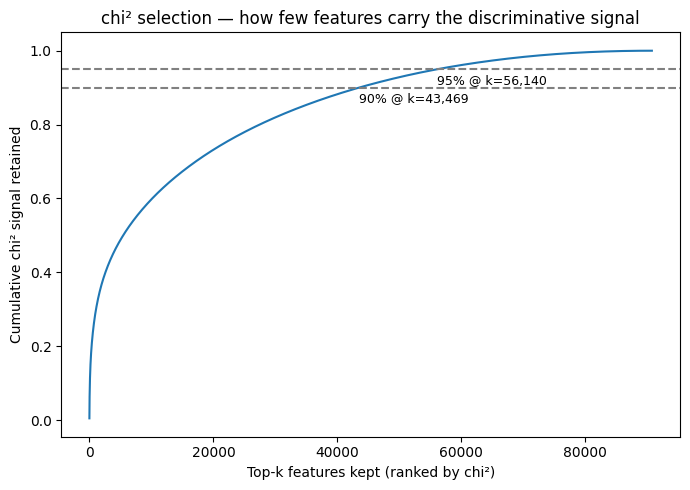

  90% of chi² signal -> top 43,469 features
  95% of chi² signal -> top 56,140 features
  99% of chi² signal -> top 74,530 features

SelectKBest(k=56140): 90,725 -> 56,140 features


In [11]:
# 7.2 / chi2 feature selection — make the dimensionality reduction explicit (TRAIN ONLY)
# Mirrors the coverage-curve logic from 6.2, but in chi² space: how few features carry the signal?

vec_probe = build_tfidf(use_lemma=False, ngram_range=(1, 2), min_df=5)   # match your chosen encoder
X_probe   = vec_probe.fit_transform(train_df["clean_eda"])
y_probe   = train_df["sentiment"].to_numpy()
terms     = np.array(vec_probe.get_feature_names_out())
print(f"Features before selection: {X_probe.shape[1]:,}")

# One chi² score per feature against the 3-class label (sklearn handles multiclass directly)
chi_scores, _ = chi2(X_probe, y_probe)
chi_sorted    = np.sort(chi_scores)[::-1]
retained      = np.cumsum(chi_sorted) / chi_sorted.sum()

plt.figure(figsize=(7, 5))
plt.plot(np.arange(1, len(retained) + 1), retained)
for tgt in (0.90, 0.95):
    k = int(np.searchsorted(retained, tgt) + 1)
    plt.axhline(tgt, ls="--", color="grey")
    plt.text(k, tgt - 0.04, f"{tgt:.0%} @ k={k:,}", fontsize=9)
plt.xlabel("Top-k features kept (ranked by chi²)")
plt.ylabel("Cumulative chi² signal retained")
plt.title("chi² selection — how few features carry the discriminative signal")
plt.tight_layout(); plt.show()

CHI2_K = {tgt: int(np.searchsorted(retained, tgt) + 1) for tgt in (0.90, 0.95, 0.99)}
for tgt, k in CHI2_K.items():
    print(f"  {tgt:.0%} of chi² signal -> top {k:,} features")

# Demonstrate the actual reduction at the 95% point
K        = min(CHI2_K[0.95], X_probe.shape[1])
selector = SelectKBest(chi2, k=K).fit(X_probe, y_probe)
X_reduced = selector.transform(X_probe)
print(f"\nSelectKBest(k={selector.k}): {X_probe.shape[1]:,} -> {X_reduced.shape[1]:,} features")

## 9/ Classifiers

In [12]:
def make_candidates():
    # Fresh, unfitted estimators each call (cloned before fitting in the loop).
    return [
        ("ComplementNB",       ComplementNB()),
        ("MultinomialNB",      MultinomialNB()),
        ("LogReg C=1",         LogisticRegression(C=1.0, max_iter=2000,
                                                  class_weight="balanced")),
        ("LogReg C=2",         LogisticRegression(C=2.0, max_iter=2000,
                                                  class_weight="balanced")),
        ("LinearSVC C=0.5",    LinearSVC(C=0.5, class_weight="balanced")),
        ("LinearSVC C=1",      LinearSVC(C=1.0, class_weight="balanced")),
    ]

#### Main cross-validation (still need to be improved)

In [ ]:
y_train = train_df["sentiment"].to_numpy()
y_val   = val_df["sentiment"].to_numpy()

rows = []
for ngram in [(1, 1), (1, 2)]:
    for min_df in [3, 5]:
        vec  = build_tfidf(ngram_range=ngram, min_df=min_df)
        Xtr  = vec.fit_transform(train_df["clean_eda"])
        Xvl  = vec.transform(val_df["clean_eda"])
        nfeat = Xtr.shape[1]

        k_grid = sorted({COVERAGE_FEATURES[0.95], COVERAGE_FEATURES[0.99], nfeat})
        for k in k_grid:
            k_eff = min(k, nfeat)
            sel   = SelectKBest(chi2, k=k_eff).fit(Xtr, y_train)
            Xtr_s = sel.transform(Xtr)
            Xvl_s = sel.transform(Xvl)
            for name, est in make_candidates():
                clf = clone(est).fit(Xtr_s, y_train)
                f1  = f1_score(y_val, clf.predict(Xvl_s), average="macro")
                rows.append({"clf": name, "ngram": str(ngram), "min_df": min_df,
                             "k": k_eff, "val_macroF1": round(f1, 4)})

results = pd.DataFrame(rows).sort_values("val_macroF1", ascending=False).reset_index(drop=True)
print("Top 10 configurations by validation macro-F1:")
print(results.head(10).to_string(index=False))

best = results.iloc[0]
print("\nBest config:")
print(best.to_string())

#### Does lemmatization help enough to risk it?

In [ ]:
best_ngram  = eval(best["ngram"])
best_min_df = int(best["min_df"])
best_k      = int(best["k"])
best_name   = best["clf"]
best_est    = dict(make_candidates())[best_name]

def val_macro_f1(vectorizer):
    Xtr = vectorizer.fit_transform(train_df["clean_eda"])
    Xvl = vectorizer.transform(val_df["clean_eda"])
    k_eff = min(best_k, Xtr.shape[1])
    sel   = SelectKBest(chi2, k=k_eff).fit(Xtr, y_train)
    clf   = clone(best_est).fit(sel.transform(Xtr), y_train)
    return f1_score(y_val, clf.predict(sel.transform(Xvl)), average="macro")

f1_native = val_macro_f1(build_tfidf_native(best_ngram, best_min_df))
f1_lemma  = val_macro_f1(build_tfidf_lemma (best_ngram, best_min_df))
print(f"Native encoder val macro-F1 : {f1_native:.4f}")
print(f"Lemma  encoder val macro-F1 : {f1_lemma:.4f}")
print(f"Lemmatization delta         : {f1_lemma - f1_native:+.4f}")

The delta is even slightly negative, suggests that the encoder using lemmatized tokens works slightly worse, thus it is decisive that we use the native vectorizer

#### Define final pipeline, and derive test metrics

In [29]:
# Final deployable pipeline (native encoder -> chi2 -> best classifier)
final_pipeline = Pipeline([
    ("tfidf", build_tfidf_native(ngram_range=best_ngram, min_df=best_min_df)),
    ("chi2",  SelectKBest(chi2, k=best_k)),
    ("clf",   clone(best_est)),
])

# Refit on train + val
X_trval = pd.concat([train_df["clean_eda"], val_df["clean_eda"]], ignore_index=True)
y_trval = np.concatenate([y_train, y_val])

# Guard: k must not exceed the train+val feature count
_probe = build_tfidf_native(best_ngram, best_min_df).fit(X_trval)
final_pipeline.set_params(chi2__k=min(best_k, len(_probe.vocabulary_)))
final_pipeline.fit(X_trval, y_trval)

y_test = test_df["sentiment"].to_numpy()
y_pred = final_pipeline.predict(test_df["clean_eda"])

print(f"TEST macro-F1: {f1_score(y_test, y_pred, average='macro'):.4f}\n")
print(classification_report(y_test, y_pred, target_names=["Negative", "Neutral", "Positive"]))
print("Confusion matrix (rows=true, cols=pred) order [-1, 0, 1]:")
print(confusion_matrix(y_test, y_pred, labels=[-1, 0, 1]))

print("\nPer-domain macro-F1:")
for dom in ["Review", "Tweet"]:
    m = test_df["Type"] == dom
    if m.any():
        print(f"  {dom:>7}: {f1_score(y_test[m.values], y_pred[m.values], average='macro'):.4f}"
              f"   (n={m.sum():,})")

TEST macro-F1: 0.6825

              precision    recall  f1-score   support

    Negative       0.76      0.73      0.75     13468
     Neutral       0.48      0.58      0.52      9527
    Positive       0.81      0.74      0.78     15267

    accuracy                           0.70     38262
   macro avg       0.69      0.68      0.68     38262
weighted avg       0.71      0.70      0.70     38262

Confusion matrix (rows=true, cols=pred) order [-1, 0, 1]:
[[ 9872  2802   794]
 [ 2252  5479  1796]
 [  871  3066 11330]]

Per-domain macro-F1:
   Review: 0.6665   (n=30,749)
    Tweet: 0.5589   (n=7,513)


The overall F1 is around 0.68!

## 10/ Pickle the model